# NuAncestor Telescope Visibility: Inclination Comparison

This notebook compares telescope visibility results obtained from three FreeFlyer simulations. Three circular orbits are considered with inclinations 0°, 20°, and 40°, all with a semi-major axis of 23,200 km.

For each orbit, the night contact windows, elevation tracking speed, and azimuthal tracking speed are compared. The notebook also calculates the mean night contacts/day, equivalent interval between contacts, tracking-speed range, per-telescope visibility statistics, and percentage visibility change relative to the i=0° orbit.

Version 07/2026 by Pedro de S. C. Leonardo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

In [2]:
# Main folder containing the three simulation folders
BASE = Path("/Users/pedroleonardo/Desktop/nuAncestor/Code/NuAncestor/FreeFlyer/All_Results/Inclination Comparison")

# Settings to change !!
SEMI_MAJOR_AXIS = 23200
DAYS = 30
SAVE_FIGURES = False
SHOW_REQUIREMENTS = False
MAX_ELEVATION_SPEED = 10
MAX_AZIMUTHAL_SPEED = 600

In [3]:
stations = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
colors = ["r", "blueviolet", "cyan", "orange", "lime"]

# Inclinations are ordered from top to bottom in the plots
cases = [
    {"name": "i = 0°", "inclination": 0, "folder": "Results_i0"},
    {"name": "i = 20°", "inclination": 20, "folder": "Results_i20"},
    {"name": "i = 40°", "inclination": 40, "folder": "Results_i40"},
]


# Read one FreeFlyer results file
def read_result(folder, filename):
    path = BASE / folder / filename
    return pd.read_csv(path, skiprows=3, sep=r"\s+").to_numpy(dtype=float)

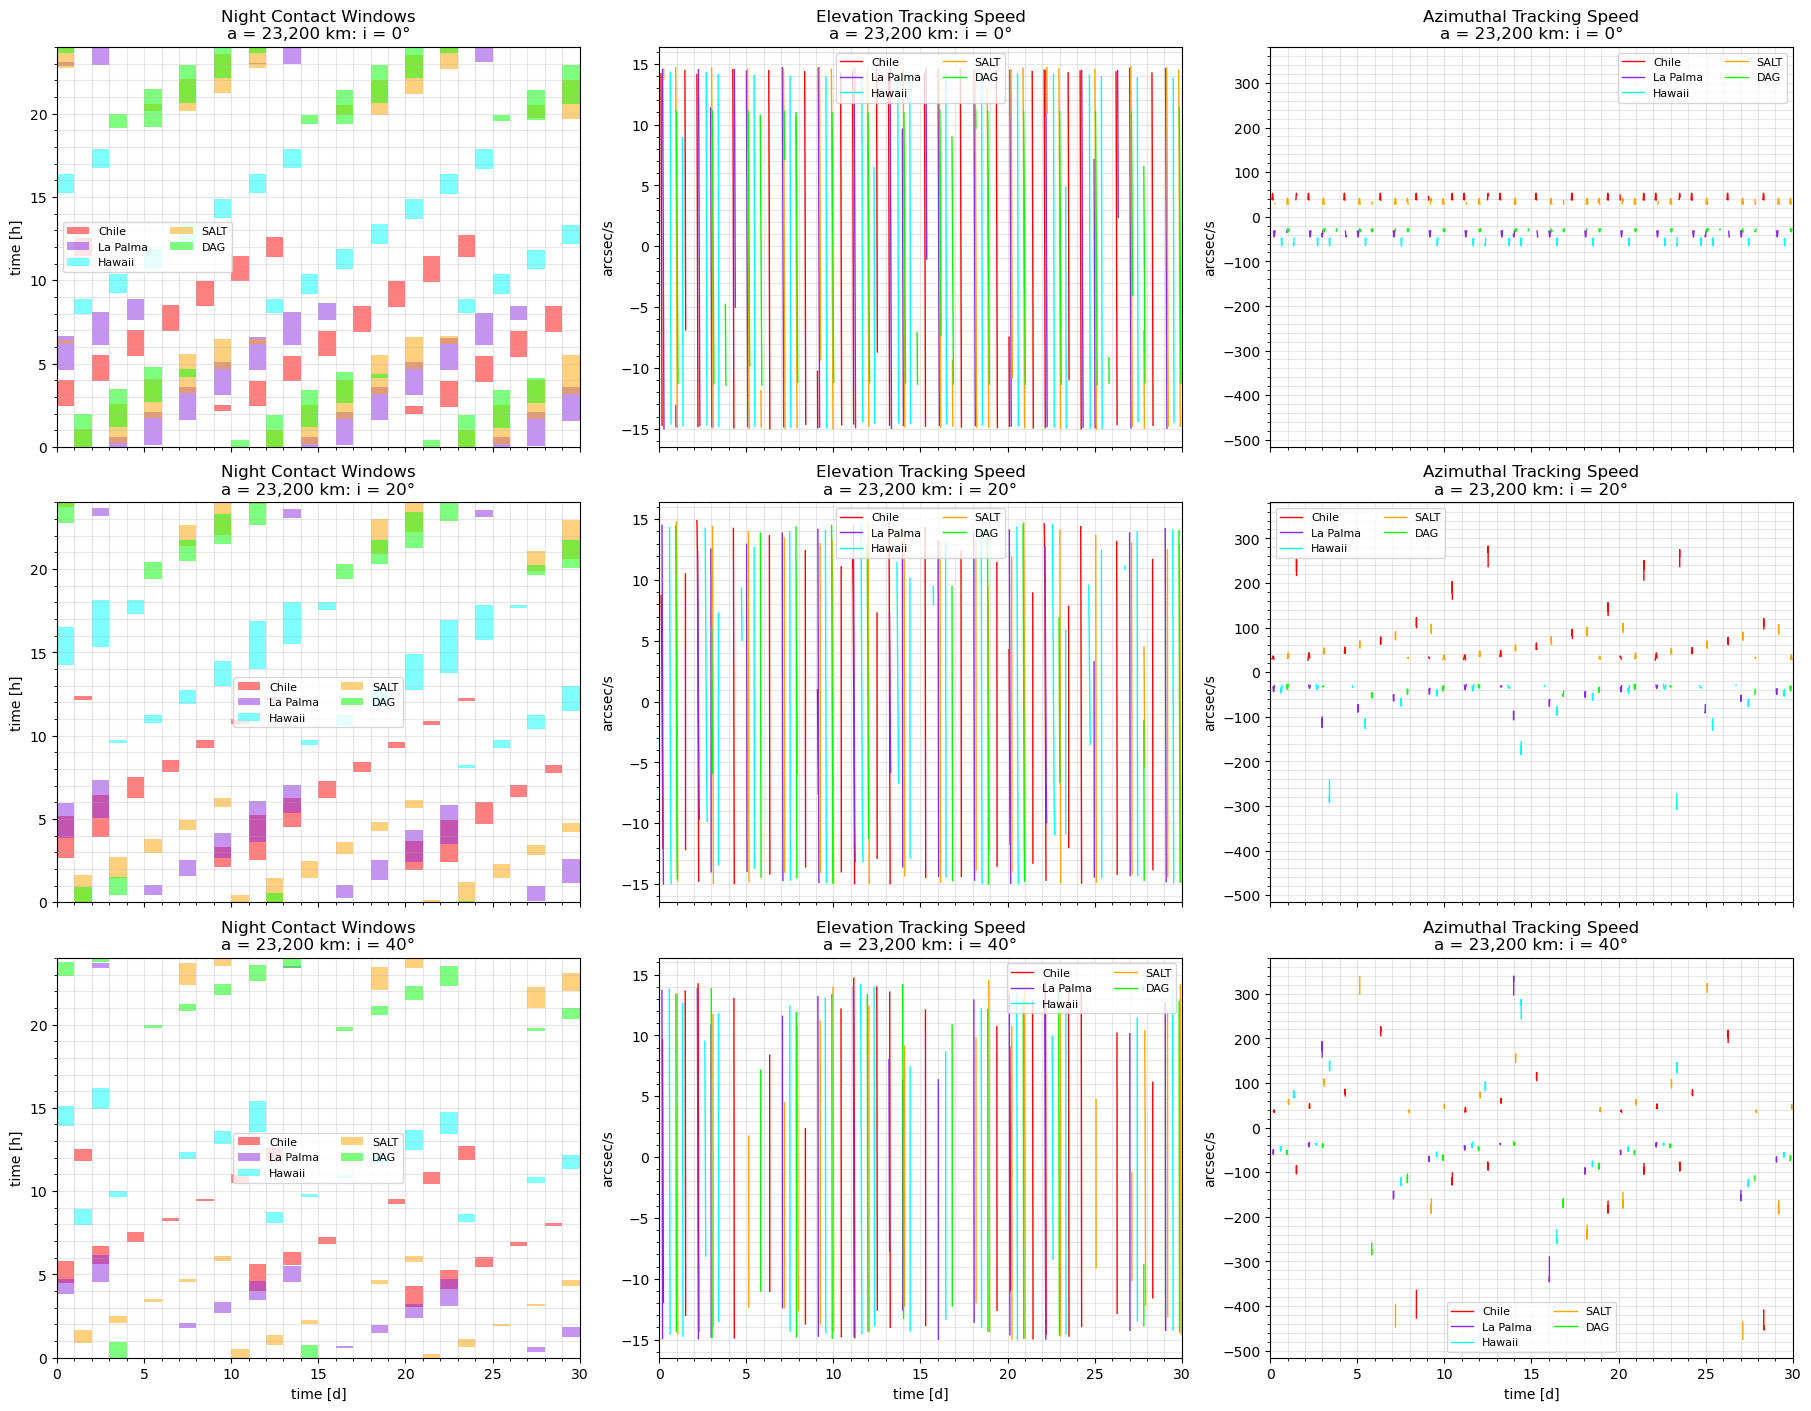

In [4]:
def plot_contact_windows(ax, folder, title):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    day = np.floor(time) + 0.5
    hour = (time - np.floor(time)) * 24
    dt_hours = np.median(np.diff(time)) * 24

    for i, station in enumerate(stations):
        visible = data[:, i + 1] == 1
        ax.bar(day[visible], np.full(visible.sum(), dt_hours),
               width=1, bottom=hour[visible],
               color=colors[i], alpha=0.5, label=station)

    ax.set_title(title)
    ax.set_ylabel("time [h]")
    ax.set_xlim(0, DAYS)
    ax.set_ylim(0, 24)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def plot_speed(ax, folder, filename, title, requirement=None):
    data = read_result(folder, filename)
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    values = data[:, 1:].copy()

    # Ignore zeros outside contact windows
    values[values == 0] = np.nan

    for i, station in enumerate(stations):
        ax.plot(time, values[:, i], color=colors[i],
                linewidth=1, label=station)

    # Optional telescope requirement
    if SHOW_REQUIREMENTS and requirement is not None:
        ax.axhline(requirement, color="black", linestyle="--",
                   linewidth=1.2,
                   label=f"Requirement: {requirement:g} arcsec/s")

    ax.set_title(title)
    ax.set_ylabel("arcsec/s")
    ax.set_xlim(0, DAYS)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 14),
    sharex="col",
    sharey="col",
    constrained_layout=True)

for row, case in enumerate(cases):
    subtitle = f"a = {SEMI_MAJOR_AXIS:,} km: {case['name']}"

    plot_contact_windows(
        axes[row, 0], case["folder"],
        f"Night Contact Windows\n{subtitle}")

    plot_speed(
        axes[row, 1], case["folder"],
        "Elevation Speed.txt",
        f"Elevation Tracking Speed\n{subtitle}",
        requirement=MAX_ELEVATION_SPEED)

    plot_speed(
        axes[row, 2], case["folder"],
        "Azimuthal Speed.txt",
        f"Azimuthal Tracking Speed\n{subtitle}",
        requirement=MAX_AZIMUTHAL_SPEED)

for ax in axes[-1, :]:
    ax.set_xlabel("time [d]")

# Change SAVE_FIGURES to True to save the figure
if SAVE_FIGURES:
    output = BASE / "comparison_plots"
    output.mkdir(exist_ok=True)

    fig.savefig(
        output / f"inclination_comparison_a{SEMI_MAJOR_AXIS}.png",
        dpi=300,
        bbox_inches="tight")

plt.show()

In [5]:
MU_EARTH = 398600.4418  # Earth's gravitational parameter [km^3/s^2]


def contact_statistics(folder):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    in_contact = data[:, 1:] == 1

    previous = np.vstack((
        np.zeros((1, in_contact.shape[1]), dtype=bool),
        in_contact[:-1]))
    contact_starts = in_contact & ~previous

    duration_days = time[-1] - time[0]
    contacts_per_day = contact_starts.sum(axis=0) / duration_days
    mean_contacts_per_day = contacts_per_day.mean()

    mean_interval_hours = (
        24 / mean_contacts_per_day
        if mean_contacts_per_day > 0 else np.nan)

    return mean_contacts_per_day, mean_interval_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    return (
        (min(maxima), max(maxima))
        if maxima else (np.nan, np.nan))


def fmt(value, decimals=2):
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


period_hours = (
    2 * np.pi * np.sqrt(SEMI_MAJOR_AXIS**3 / MU_EARTH) / 3600)
columns = {}

for case in cases:
    contacts_per_day, interval_hours = contact_statistics(case["folder"])
    speed_min, speed_max = tracking_speed_range(case["folder"])

    columns[case["name"]] = [
        f"{SEMI_MAJOR_AXIS:,} km",
        f"{period_hours:.3f} h",
        f"{case['inclination']}°",
        f"{contacts_per_day:.3f}",
        f"{interval_hours:.2f} h",
        f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Mean night contacts/day per telescope",
    "Equivalent mean interval between night contacts",
    "Max. tracking speed for different latitudes"])

summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

,i = 0°,i = 20°,i = 40°
Orbit,,,
Semi-major axis,"23,200 km","23,200 km","23,200 km"
Orbit period,9.769 h,9.769 h,9.769 h
Orbit inclination,0°,20°,40°
Mean night contacts/day per telescope,0.733,0.613,0.540
Equivalent mean interval between night contacts,32.72 h,39.13 h,44.44 h
Max. tracking speed for different latitudes,26.99 – 29.24 arcsec/s,30.3 – 31.73 arcsec/s,35.63 – 36.97 arcsec/s


In [6]:
# Telescopes to include in the statistics
SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_intervals(time, visible):
    """Return the start and end time of every continuous contact window."""
    dt = np.median(np.diff(time))
    end_of_data = time[-1] + dt

    # Detect transitions into and out of contact
    changes = np.diff(visible.astype(int))
    starts = list(time[1:][changes == 1])
    ends = list(time[1:][changes == -1])

    # Include contacts active at the start or end
    if visible[0]:
        starts.insert(0, time[0])
    if visible[-1]:
        ends.append(end_of_data)

    return np.array(starts), np.array(ends), end_of_data


def visibility_statistics(time, visible):
    starts, ends, end_of_data = contact_intervals(time, visible)
    durations = (ends - starts) * 24

    if durations.size:
        median_duration = np.median(durations)
        maximum_duration = np.max(durations)
        total_contact = np.sum(durations)
    else:
        median_duration = np.nan
        maximum_duration = np.nan
        total_contact = 0.0

    # Include gaps at the beginning and end
    if starts.size:
        gaps = [starts[0] - time[0]]
        gaps.extend(starts[1:] - ends[:-1])
        gaps.append(end_of_data - ends[-1])
        maximum_gap = np.max(gaps) * 24
    else:
        maximum_gap = (end_of_data - time[0]) * 24

    return {
        "total_contact_h": total_contact,
        "median_duration_h": median_duration,
        "maximum_duration_h": maximum_duration,
        "maximum_gap_h": maximum_gap}


case_by_inclination = {
    case["inclination"]: case for case in cases}

baseline = read_result(
    case_by_inclination[0]["folder"], "InContact.txt")
baseline = baseline[
    (baseline[:, 0] >= 0) & (baseline[:, 0] <= DAYS)]

rows = []

for inclination in [20, 40]:
    compared = read_result(
        case_by_inclination[inclination]["folder"], "InContact.txt")
    compared = compared[
        (compared[:, 0] >= 0) & (compared[:, 0] <= DAYS)]

    if baseline.shape != compared.shape or not np.allclose(
        baseline[:, 0], compared[:, 0]):
        raise ValueError(
            f"Time grids do not match for i = 0° and i = {inclination}°.")

    time = baseline[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)

        baseline_visible = baseline[:, i + 1] == 1
        compared_visible = compared[:, i + 1] == 1

        baseline_stats = visibility_statistics(
            time, baseline_visible)
        compared_stats = visibility_statistics(
            time, compared_visible)

        difference_hours = (
            compared_stats["total_contact_h"]
            - baseline_stats["total_contact_h"])

        change_percent = (
            100 * difference_hours / baseline_stats["total_contact_h"]
            if baseline_stats["total_contact_h"] > 0 else np.nan)

        rows.append({
            "Inclination [deg]": inclination,
            "Telescope": station,
            "i = 0 total contact [h]":
                baseline_stats["total_contact_h"],
            "Compared total contact [h]":
                compared_stats["total_contact_h"],
            "Difference from i = 0 [h]": difference_hours,
            "Visibility change from i = 0 [%]": change_percent,
            "i = 0 median duration [h]":
                baseline_stats["median_duration_h"],
            "Compared median duration [h]":
                compared_stats["median_duration_h"],
            "i = 0 maximum duration [h]":
                baseline_stats["maximum_duration_h"],
            "Compared maximum duration [h]":
                compared_stats["maximum_duration_h"],
            "i = 0 maximum gap [h]":
                baseline_stats["maximum_gap_h"],
            "Compared maximum gap [h]":
                compared_stats["maximum_gap_h"]})


contact_stats = pd.DataFrame(rows).round(2)
display(contact_stats)

,Inclination [deg],Telescope,i = 0 total contact [h],Compared total contact [h],Difference from i = 0 [h],Visibility change from i = 0 [%],i = 0 median duration [h],Compared median duration [h],i = 0 maximum duration [h],Compared maximum duration [h],i = 0 maximum gap [h],Compared maximum gap [h]
0,20,Chile,29.23,23.20,-6.03,-20.64,1.53,0.77,1.57,2.73,47.97,48.83
1,20,La Palma,35.97,21.80,-14.17,-39.39,1.97,1.32,2.00,2.50,47.53,65.27
2,20,Hawaii,22.27,27.47,5.20,23.35,1.17,0.83,1.17,3.17,48.37,48.67
3,20,SALT,45.43,24.07,-21.37,-47.03,2.33,1.08,2.33,2.40,47.17,48.63
4,20,DAG,39.20,17.30,-21.90,-55.87,2.27,1.37,2.33,2.17,47.23,115.57
5,40,Chile,29.23,13.47,-15.77,-53.93,1.53,0.70,1.57,1.60,47.97,97.97
6,40,La Palma,35.97,10.13,-25.83,-71.83,1.97,0.65,2.00,1.60,47.53,115.63
7,40,Hawaii,22.27,12.83,-9.43,-42.37,1.17,0.77,1.17,1.90,48.37,97.90
8,40,SALT,45.43,11.20,-34.23,-75.35,2.33,0.43,2.33,1.37,47.17,98.17
9,40,DAG,39.20,9.17,-30.03,-76.62,2.27,0.67,2.33,1.40,47.23,116.13


### Contact statistics

- **Telescope:** Ground-based telescope for which the contact statistics are calculated.
- **i = 0 total contact [h]:** Total usable contact time for the baseline orbit.
- **Compared total contact [h]:** Total usable contact time for the inclined orbit.
- **Difference from i = 0 [h]:** Absolute contact-time change relative to \(i=0^\circ\). Positive values indicate more contact and negative values indicate less.
- **Visibility change from i = 0 [%]:** Percentage change in total contact relative to the baseline orbit.
- **Median duration [h]:** Median duration of an individual continuous contact window.
- **Maximum duration [h]:** Duration of the longest continuous contact window.
- **Maximum gap [h]:** Longest continuous period without contact, including gaps at the beginning and end of the analysis.

In [13]:
orbit_rows = []

for case in cases:
    data = read_result(case["folder"], "InContact.txt")
    data = data[
        (data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)
        visible = data[:, i + 1] == 1

        stats = visibility_statistics(time, visible)

        orbit_rows.append({
            "Inclination [deg]": case["inclination"],
            "Telescope": station,
            "Total contact [h]": stats["total_contact_h"],
            "Median duration [h]": stats["median_duration_h"],
            "Maximum duration [h]": stats["maximum_duration_h"],
            "Maximum gap [h]": stats["maximum_gap_h"]})


orbit_stats = pd.DataFrame(orbit_rows)

summary_stats = (
    orbit_stats
    .groupby("Inclination [deg]", as_index=False)
    .mean(numeric_only=True)
    .rename(columns={
        "Total contact [h]": "Mean total contact [h]",
        "Median duration [h]": "Mean median duration [h]",
        "Maximum duration [h]": "Mean maximum duration [h]",
        "Maximum gap [h]": "Mean maximum gap [h]"})
    .round(2))

display(summary_stats)

,Inclination [deg],Mean total contact [h],Mean median duration [h],Mean maximum duration [h],Mean maximum gap [h]
0,0,34.42,1.85,1.88,47.65
1,20,22.77,1.07,2.59,65.39
2,40,11.36,0.64,1.57,105.16


In [14]:
def visibility_label(percent, hours):
    if pd.isna(percent):
        return "Undefined"
    if percent > 0:
        return f"{percent:.2f}% more ({hours:.2f} h more)"
    if percent < 0:
        return f"{abs(percent):.2f}% less ({abs(hours):.2f} h less)"
    return "No change"


visibility_percent = (
    contact_stats
    .pivot(
        index="Telescope",
        columns="Inclination [deg]",
        values="Visibility change from i = 0 [%]")
    .reindex(SELECTED_TELESCOPES))

visibility_hours = (
    contact_stats
    .pivot(
        index="Telescope",
        columns="Inclination [deg]",
        values="Difference from i = 0 [h]")
    .reindex(SELECTED_TELESCOPES))

visibility_comparison = pd.DataFrame(
    index=SELECTED_TELESCOPES)

for inclination in visibility_percent.columns:
    visibility_comparison[
        f"i = {inclination}° compared with i = 0°"] = [
            visibility_label(percent, hours)
            for percent, hours in zip(
                visibility_percent[inclination],
                visibility_hours[inclination])]

visibility_comparison.index.name = "Telescope"
display(visibility_comparison)

,i = 20° compared with i = 0°,i = 40° compared with i = 0°
Telescope,,
Chile,20.64% less (6.03 h less),53.93% less (15.77 h less)
La Palma,39.39% less (14.17 h less),71.83% less (25.83 h less)
Hawaii,23.35% more (5.20 h more),42.37% less (9.43 h less)
SALT,47.03% less (21.37 h less),75.35% less (34.23 h less)
DAG,55.87% less (21.90 h less),76.62% less (30.03 h less)
